In [1]:
# setup and load libraries
import numpy as np
import sys, cv2, time, torch, scipy.io
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from models.unet import init_UNet
from utils.dataset import MNIST
from inverse.orthogonal import LinearInverse, GaussianLinearInverse, batch_recon
from torchmetrics import StructuralSimilarityIndexMeasure as MetricSSIM
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ExponentialLR
from scipy.linalg import subspace_angles
from scipy.stats import skew, kurtosis

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False,
                "axes.grid": False, "figure.facecolor": "white"}
sns.set_theme(style="ticks", rc=custom_params)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

save_figure = True
if save_figure:
    plt.rcParams['figure.dpi'] = 300

### Set Up Data

In [3]:
data = MNIST()
train_set = data.train_set()
test_set = data.test_set()

test_numpy = test_set
test_torch = torch.tensor(test_set).permute([0, 3, 1, 2]).to(device)

In [4]:
# setup
train_torch = torch.from_numpy(train_set)
np_size = [*train_set.shape[-3:]]
im_size = test_torch.size()[1:]
n_pixel = np.prod(im_size)
avg_im = torch.mean(train_torch, dim=0).permute([2, 0, 1])

In [5]:
model_path = './assets/unet_mnist.pt'
model = init_UNet({'num_blocks':2})
model.load_state_dict(torch.load(model_path))
model = model.to(device).eval()

In [6]:
loss = torch.nn.MSELoss(reduction='sum')
def compute_loss(recon, test, test_torch):
    mse_val = (loss(test_torch, recon) / recon.shape[0]).item()
    recon_numpy = recon.permute([0, 2, 3, 1]).detach().cpu().numpy()
    psnr_val = psnr(test, recon_numpy)
    
    return mse_val, psnr_val

### Evalulate Performance

In [7]:
# compute PCA solution
image_vec = train_torch.permute([0, 3, 2, 1]).flatten(1).numpy()
pca = PCA(n_components=image_vec.shape[-1])
pca.fit(image_vec)

# n_comp, n_features
pcs = pca.components_

In [8]:
# load matrix
file_path = './olm_2025/MNIST/olm_seq_mnist.npy'

with open(file_path, 'rb') as fl:
    seq_mtx = np.load(fl)       
    seq_mtx = torch.from_numpy(seq_mtx)

In [9]:
samples = [8, 16, 32, 64, 128]
base_path = './olm_2025/MNIST/all_digit/%d_MSE_mnist.npy'
psnr_val = np.zeros((3, len(samples)))

for index in tqdm(range(len(samples))):
    n_sample = samples[index]
    
    # setup linear inverse object
    solver = LinearInverse(n_sample, im_size, model).to(device)
    solver.h_init = 0.10
    solver.beta = 0.10
    
    solver.run_avg = True
    solver.num_avg = 32
    recon_batch = 64
    
    # 1. PCA + Denoiser    
    solver.assign(torch.from_numpy(pca.components_[:n_sample, :]).to(device))
    solver_gpu = torch.nn.DataParallel(solver)    
    recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
    
    # MSE and PNSR
    loss_val = compute_loss(recon, test_set, test_torch)
    psnr_val[0, index] = loss_val[1]

    # 2. Optimized Measuremnet + Denoiser
    order = 5
    file_path = base_path % n_sample
    with open(file_path, 'rb') as fl:
        for count in range(order):
            opt_mtx = np.load(fl)
        
    opt_mtx = torch.from_numpy(opt_mtx).to(device)
    solver.assign(opt_mtx)
    solver_gpu = torch.nn.DataParallel(solver)
    
    recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
    
    # MSE and PNSR
    loss_val = compute_loss(recon, test_set, test_torch)
    psnr_val[1, index] = loss_val[1]
    
    # 3. Greedy OLM
    solver.assign(seq_mtx[:n_sample, :].to(device))
    solver_gpu = torch.nn.DataParallel(solver)    
    recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
    
    # MSE and PNSR
    loss_val = compute_loss(recon, test_set, test_torch)
    psnr_val[2, index] = loss_val[1]

100%|█████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:46<00:00, 21.39s/it]


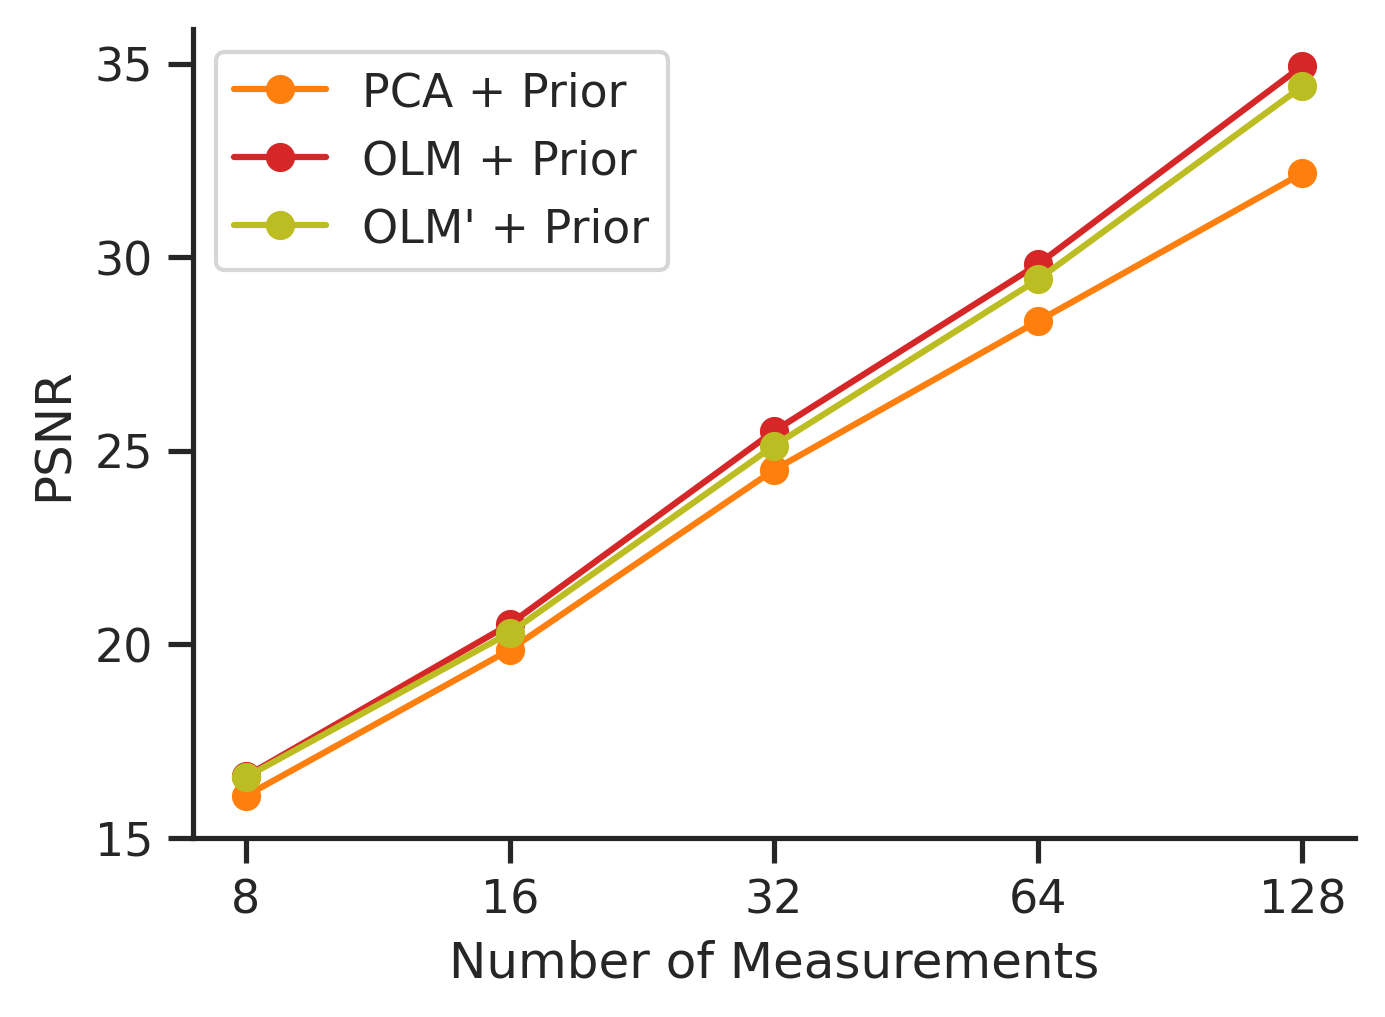

In [10]:
fig = plt.figure(figsize=(5, 3.5))

n_curve = 3
color = ['tab:orange', 'tab:red', 'tab:olive']
for idx in range(n_curve):
    plt.plot(samples, psnr_val[idx, :], '-o', color=color[idx])
    
plt.xscale('log')
plt.xlabel('Number of Measurements')
plt.xticks([8, 16, 32, 64, 128], 
           labels=['8', '16', '32', '64', '128'])
plt.minorticks_off()

plt.ylabel('PSNR')
plt.yticks([15, 20, 25, 30, 35])
plt.legend(['PCA + Prior', 
            'OLM + Prior',
            'OLM\' + Prior'])

plt.show()
fig.savefig('seq_comp.pdf', format='pdf', bbox_inches='tight')

In [11]:
target_shape = [-1, im_size[0], im_size[2], im_size[1]]
seq_image = seq_mtx.numpy().reshape(target_shape).transpose([0, 3, 2, 1])
seq_image.shape

(128, 28, 28, 1)

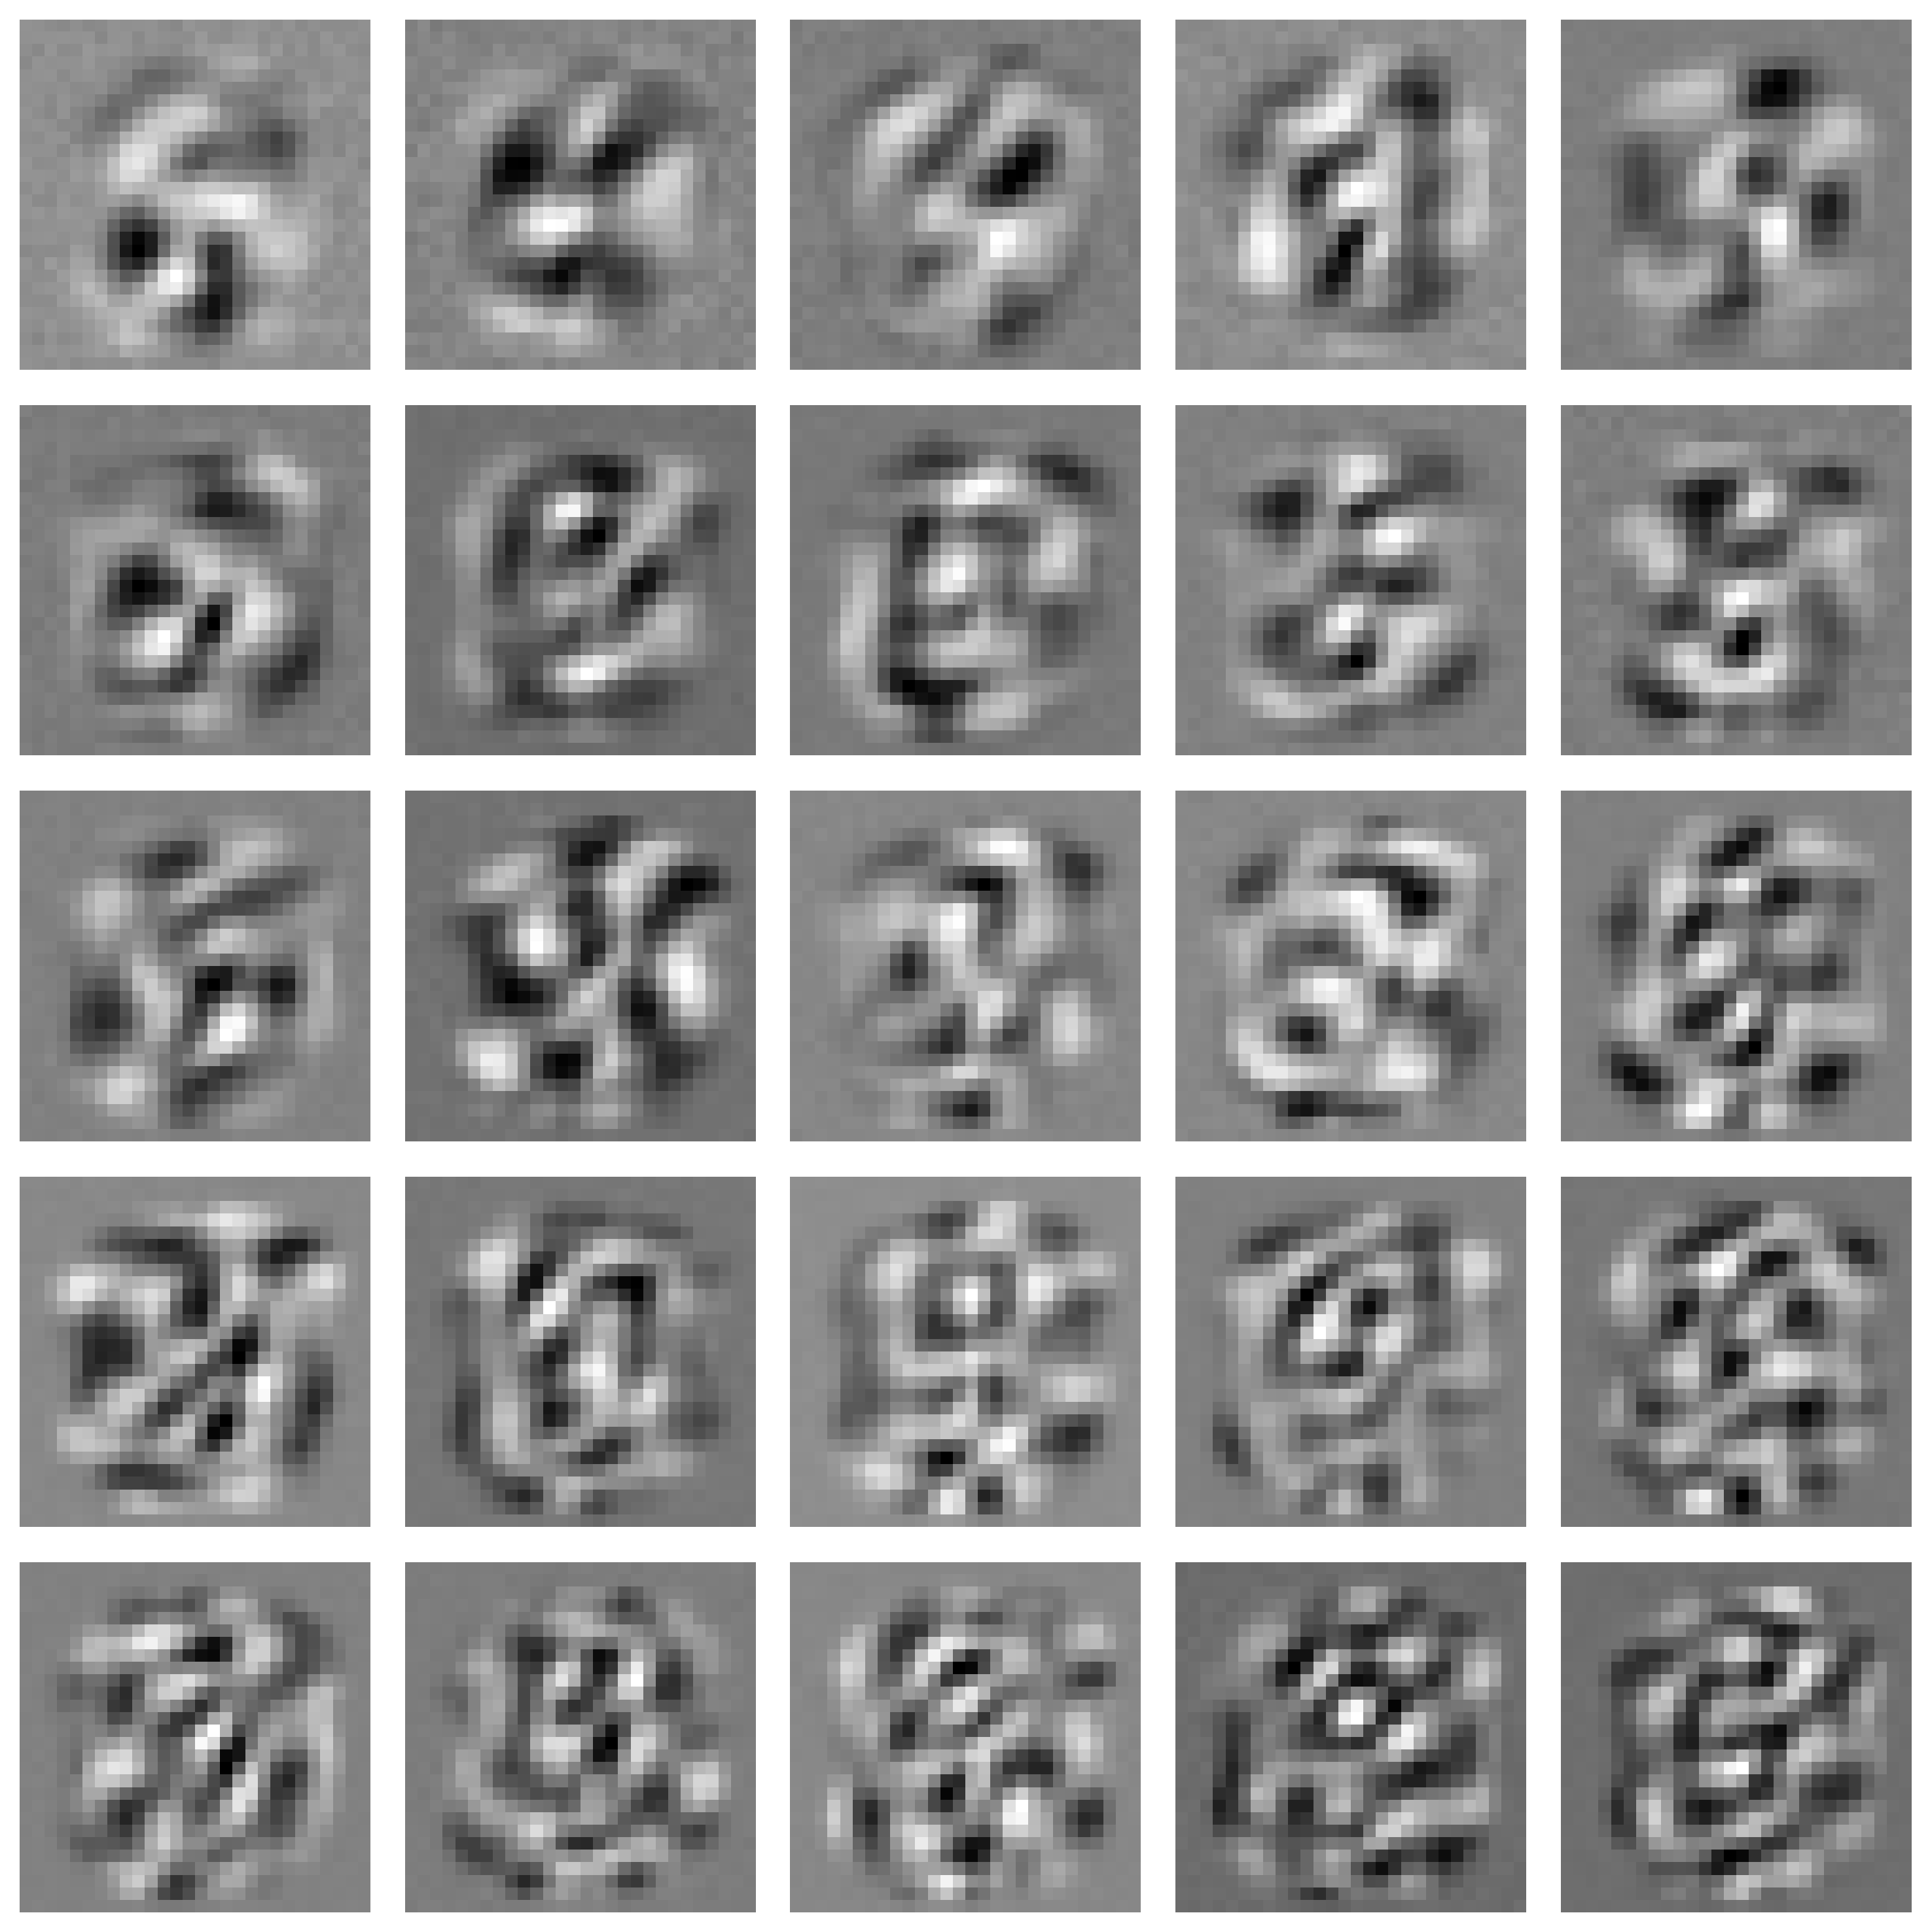

In [12]:
n_row = 5
n_col = 5

fig, axs = plt.subplots(n_row, n_col, figsize=(n_col*2, n_row*2))
for idx in range(n_row * n_col):
    # normalization
    image = seq_image[idx + 10]
    image = image - np.min(image)
    image = image / np.max(image)

    # show image
    axs.flat[idx].imshow(image, cmap='gray')
    axs.flat[idx].axis('off')

fig.tight_layout()
fig.savefig('seq_visul.pdf', format='pdf', bbox_inches='tight')